In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


# 🏟️ 4. Venue Analysis

# Which stadium hosted most matches?

In [10]:
venue_order = df['venue'].value_counts().index

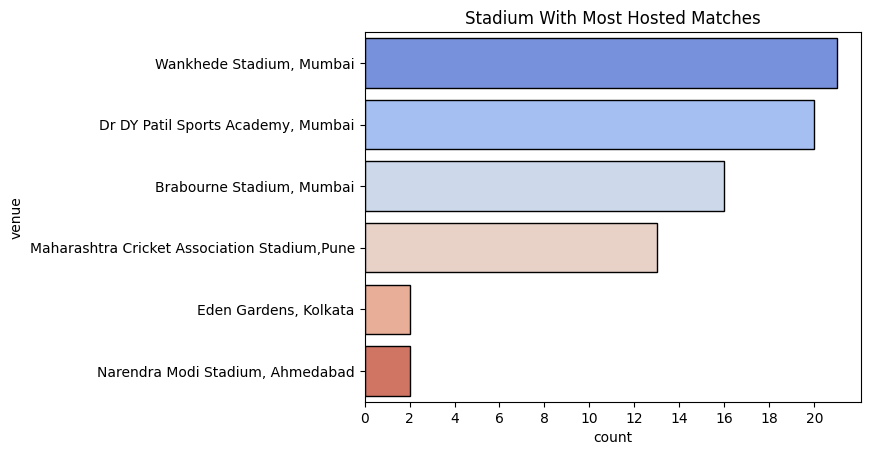

In [11]:
sns.countplot(y = 'venue',
              data = df,
              palette = 'coolwarm',
              edgecolor = 'black',
              order = venue_order
)
plt.title('Stadium With Most Hosted Matches')
plt.xticks(range(0, 21, 2))
plt.show()

# Top 5 venues by matches played.

In [12]:
top_5 = df['venue'].value_counts().head()

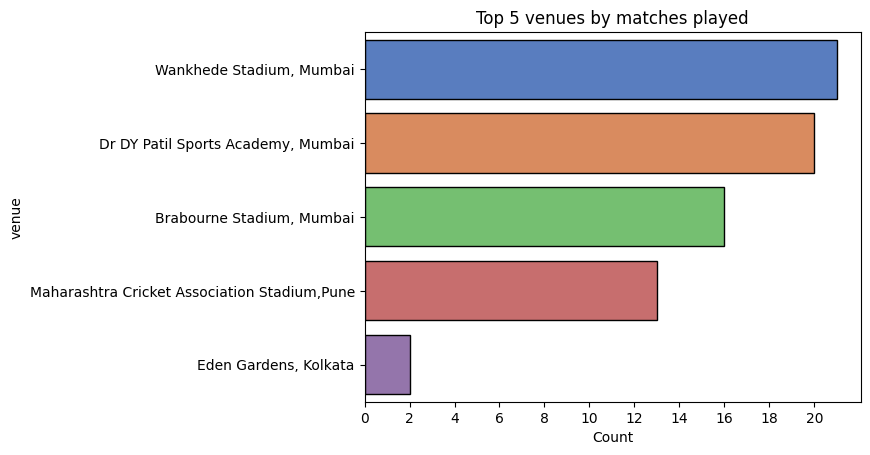

In [16]:
sns.barplot(x = top_5.values,
            y = top_5.index,
            palette = 'muted',
            edgecolor ='black'
)
plt.title('Top 5 venues by matches played')
plt.xlabel('Count')
plt.xticks(range(0, 21, 2))
plt.show()

# Which venue has most wins for any team?

In [38]:
venue_wins =(
    df.groupby('venue')['match_winner']
        .value_counts()
        .reset_index(name ='win_count')    
)

venue_wins.sort_values(by='win_count', ascending=False).head(1)

,venue,match_winner,win_count
0,"Brabourne Stadium, Mumbai",Delhi,4


# 🧠 5. Player Analysis

# Who won most Player of the Match awards?

In [14]:
(
    df['player_of_the_match']
        .value_counts()
        .head(1)
        .to_frame()
)

,count
player_of_the_match,
Kuldeep Yadav,4


# Top 10 players with awards.

In [18]:
top_10 = df['player_of_the_match'].value_counts().head(10)

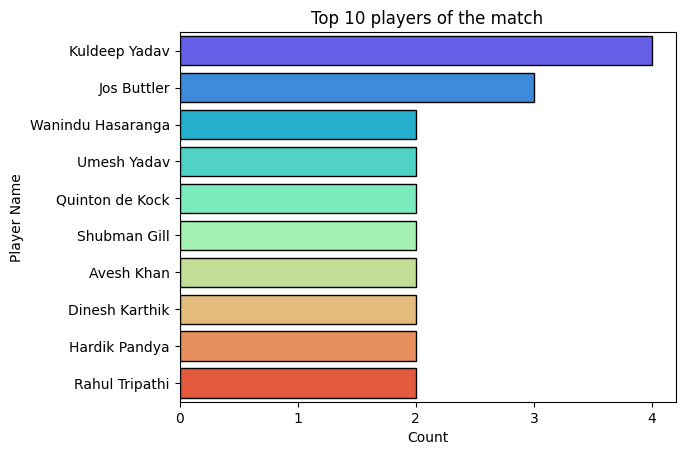

In [23]:
sns.barplot( y = top_10.index ,
             x = top_10.values,
             palette = 'rainbow',
             edgecolor = 'black'
)
plt.title('Top 10 players of the match')
plt.ylabel('Player Name')
plt.xlabel('Count')
plt.xticks(range(0, 5 ,1))
plt.show()

# Top 5 run scorers across seasons.

In [40]:
top_5 = (
    df.groupby('top_scorer')['highscore']
        .max()
        .sort_values( ascending=False)
        .head()
)

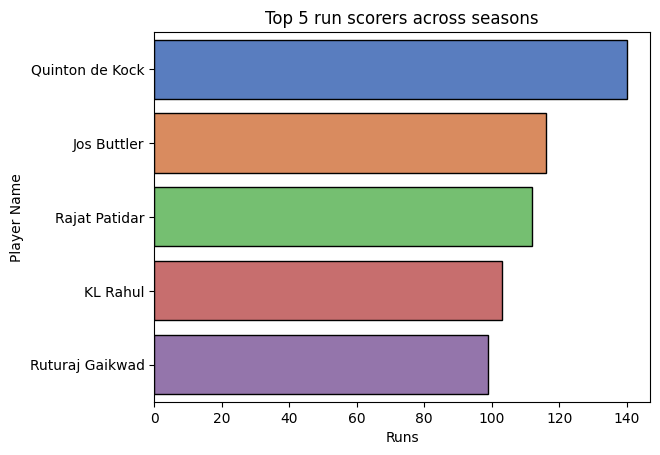

In [42]:
sns.barplot( y = top_5.index ,
             x = top_5.values,
             palette = 'muted',
             edgecolor = 'black'
)
plt.title('Top 5 run scorers across seasons')
plt.ylabel('Player Name')
plt.xlabel('Runs')
plt.show()

# 📈 6. Score Analysis

# Highest match score.

In [53]:
highest_score = (
    df.groupby('top_scorer')['highscore']
        .max().
        sort_values(ascending = False)
        .head(1)
)
highest_score.to_frame(name ='Highest_score')

,Highest_score
top_scorer,
Quinton de Kock,140


# Lowest match score.

In [55]:
lowest_score = (
    df.groupby('top_scorer')['highscore']
        .max().
        sort_values(ascending = True)
        .head(1)
)
lowest_score.to_frame(name ='lowest_score')

,lowest_score
top_scorer,
Sherfane Rutherford,28


# Top 10 average score per player.

In [19]:
avg_score_10 =(
    df.groupby('top_scorer')['highscore']
        .mean()
        .sort_values(ascending = False)
        .head(10)
)


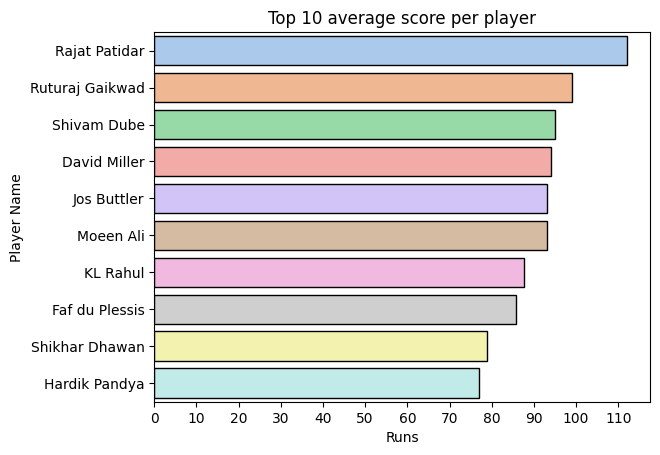

In [20]:
sns.barplot(x = avg_score_10.values,
            y = avg_score_10.index,
            palette ='pastel',
            edgecolor ='black'
)
plt.title('Top 10 average score per player')
plt.ylabel('Player Name')
plt.xlabel('Runs')
plt.xticks(range(0, 111, 10))
plt.show()

# Score distribution.

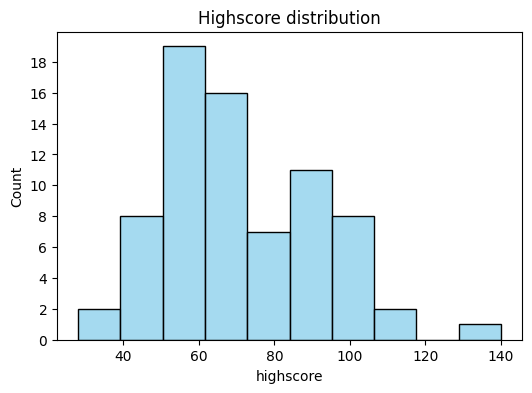

In [67]:
plt.figure(figsize=(6,4))

sns.histplot(x ='highscore',
            data = df,
            bins = 10,
            color ='skyblue'
)
plt.title('Highscore distribution')
plt.yticks(range(0, 19, 2))
plt.show()

# ⚔️ 7. Head-to-Head

# How many times MI played against CSK?

In [11]:
filter_team = df[
    ((df['team1']=='Chennai') & (df['team2']=='Mumbai'))|
    ((df['team1']=='Mumbai') & (df['team2']=='Chennai'))
]

print(f"MI has played just {filter_team.shape[0]} times against CSK.")

MI has played just 2 times against CSK.


# Who won more between them?

In [22]:
print(filter_team['match_winner']
    .value_counts()
    .to_frame(name='win_count')
)

print('\nBoth team has won equal match.')

              win_count
match_winner           
Chennai               1
Mumbai                1

Both team has won equal match.


# 📉 8. Match Result Insights

# More wins by runs or wickets?

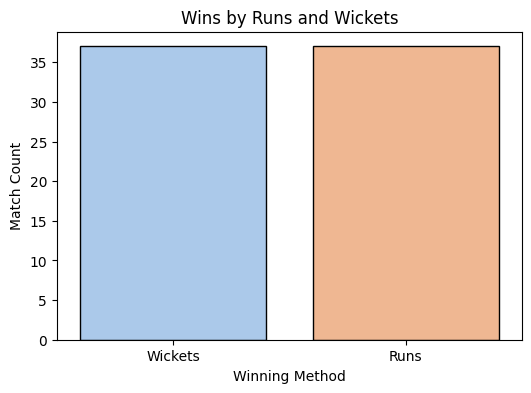

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x ='won_by',
              data = df,
              palette = 'pastel',
              edgecolor ='black'
)

plt.title('Wins by Runs and Wickets')
plt.xlabel('Winning Method')
plt.ylabel('Match Count')

plt.show()

# Biggest win margin.

In [43]:
biggest_win = df.groupby('won_by')['margin'].max()
biggest_win.to_frame(name ='biggest_margin')

,biggest_margin
won_by,
Runs,91
Wickets,9


# How many close matches? (margin < 10 runs)

In [48]:
matches = df[(df['margin'] < 10) & (df['won_by'] =='Runs')]
print(f'There are just {matches.shape[0]} close matches in the whole season.')

There are just 7 close matches in the whole season.


# 🎯 9. Final Insights Section

In [3]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
